<a href="https://colab.research.google.com/github/Michaeljo112/BP/blob/main/desercion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Este cuaderno contiene las soluciones del primer problema de la prueba técnica.<br>

#**0. Preparación de datos**

In [1]:
# Leer parquetes/librerías
import pandas as pd
from pandas.api.types import is_numeric_dtype

In [2]:
# Lectura de datos
url = 'Base_para_prueba_técnica.xlsx'
df = pd.read_excel(url)
df.head()

,NumeroId,Oficina,CapitalConsumo,Ciudad,FECHA_CORTE,CUPO_TOTAL_TC,REGIONAL,SEGMENTO_TC,INGRESO_ESTIMADO,RANGO_EDAD,...,TipoPersona,DEUDA_VENCIDA_SISTEMA_FINANCIERO,DEUDA_TOTAL_SISTEMA_FINANCIERO,SCORE,Indicador de Impacto Económico,SCORE_SOBREENDEUDAMIENTO,Improductiva.Corte,Dias.Mora.Corte,Cartera.Bruta.Corte,Calificación Propuesta Cliente
0,1,Sucursal Mayor Quito,1109.32,QUITO,2024-02-29,2900.0,QUITO,TOP,6000,De 29 a 35 a±os,...,Natural,0.00,141873.02,695.0,3.0,59.0,0.0,0,1568.18,MALO
1,2,Sucursal Guayaquil,0.00,GUAYAQUIL,2024-02-29,3000.0,COSTA,TOP,375000,De 29 a 35 a±os,...,Natural,459.99,118689.50,756.0,3.0,133.0,0.0,11,2063.58,MALO
2,3,Agencia Via a la Costa,615.01,GUAYAQUIL,2024-02-29,4000.0,COSTA,TOP,325000,De 29 a 35 a±os,...,Natural,0.00,22904.11,399.0,1.0,421.0,0.0,0,1745.95,MALO
3,4,Agencia Via a la Costa,245.51,GUAYAQUIL,2024-02-29,4000.0,COSTA,ALTO,2125,De 29 a 35 a±os,...,Natural,0.00,8860.16,567.0,4.0,118.0,0.0,0,940.79,MALO
4,5,Agencia Amazonas,1289.74,QUITO,2024-02-29,8262.0,QUITO,TOP,4750,De 36 a 45 a±os,...,Natural,1504.22,72481.93,130.0,6.0,166.0,0.0,0,8197.48,MALO


In [3]:
# Devolver tipos de valores de cada columna
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6900 entries, 0 to 6899
Data columns (total 80 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   NumeroId                                            6900 non-null   int64         
 1   Oficina                                             6900 non-null   object        
 2   CapitalConsumo                                      6900 non-null   float64       
 3   Ciudad                                              6900 non-null   object        
 4   FECHA_CORTE                                         6900 non-null   datetime64[ns]
 5   CUPO_TOTAL_TC                                       6900 non-null   float64       
 6   REGIONAL                                            6900 non-null   object        
 7   SEGMENTO_TC                                         6900 non-null   object        
 8   INGRESO_

El resumen anterior por variable muestra que no existen nulos en la tabla. <br>
Ahora estudiemos la distribución de las variables.

In [4]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
NumeroId,6900.0,3450.5,1.0,1725.75,3450.5,5175.25,6900.0,1992.002761
CapitalConsumo,6900.0,431.499007,0.0,40.73,121.36,344.69,28961.89,1177.772611
FECHA_CORTE,6900,2024-02-29 00:00:00,2024-02-29 00:00:00,2024-02-29 00:00:00,2024-02-29 00:00:00,2024-02-29 00:00:00,2024-02-29 00:00:00,NaN
CUPO_TOTAL_TC,6900.0,3839.629758,500.0,1500.0,2620.935,5000.0,56679.0,3579.299364
INGRESO_ESTIMADO,6900.0,133558.717681,340.0,1875.0,3750.0,212500.0,237938931.0,2867776.598451
NUMERO_TARJETAS_CON_CONSUMO,6900.0,2.871014,0.0,1.0,2.0,4.0,14.0,2.092831
TOTAL_SALDO_ACTUAL_TC,443.0,1339.204966,0.0,0.0,0.0,0.0,50037.0,6123.132756
TOTAL_SALDO_PROMEDIO_TC_ULTIMOS_6_MESES,405.0,1103.254444,0.0,0.0,0.0,0.0,189396.0,9711.716268
ANTIGÜEDAD_SISTEMA_FINANCIERO,6900.0,60.067681,0.0,59.0,60.0,71.0,72.0,15.343614
TOTAL_DEUDA_SBS,164.0,19136.876037,0.0,0.0,3354.015,14376.665,610140.0,57707.903073


Aparentemente, los datos no presentan un comportamiento inusual. Sin emabargo, sería bueno tener en cuenta que el **25%** de los clientes registró balances 0 para el modelo.

## Exploración de datos

In [5]:
df.columns = df.columns.str.replace(' ', '_')
df.columns

Index(['NumeroId', 'Oficina', 'CapitalConsumo', 'Ciudad', 'FECHA_CORTE',
       'CUPO_TOTAL_TC', 'REGIONAL', 'SEGMENTO_TC', 'INGRESO_ESTIMADO',
       'RANGO_EDAD', 'RANGO_INGRESO', 'NUMERO_TARJETAS_CON_CONSUMO',
       'PORCENTAJE_CUPO', 'TOTAL_SALDO_ACTUAL_TC',
       'TOTAL_SALDO_PROMEDIO_TC_ULTIMOS_6_MESES', 'TIPO_DE_TARJETA',
       'ANTIGÜEDAD_SISTEMA_FINANCIERO',
       'Peor_Rango_ultimos_12_meses_en_el_SFR', 'Ingreso_estimado_',
       'TOTAL_DEUDA_SBS', 'TOTAL_POR_VENCER_SBS',
       'TOTAL_VENCIDO_SBS__INCLUYE_NO_DEVENGA_INTERESES_',
       'TOTAL_DEMANDA_JUDICIAL_SBS', 'TOTAL_CARTERA_CASTIGADA_SBS',
       'FECHA_DE_INHABILITACION', 'TOTAL_VENCIDO_SICOM', 'TOTAL_VENCIDO_RFR',
       'PORCENTAJE_CREDITO_TC_SOBRE_TOTAL_CREDITO_CLIENTE_',
       'USO_CUPO_PORCENTAJE', 'TOTAL_CUPO',
       'TOTAL_SALDO_PROMEDIO_TC_ULTIMOS_6_MESES_1', 'EDAD', 'R_EDAD',
       'RelacLaboralFinal', 'INGRESO', 'R_INGRESO', 'PerfilClientes',
       'fecha_de_Calificacion', 'NumeroAvancesCORRIENTE',


In [6]:
n = len(df)
n_malos = sum(df["Calificación_Propuesta_Cliente"].replace({'MALO': '1', 'BUENO': '0'}).astype(int))
n_malos = n - n_malos

print('El conjunto de datos contiene %s registros.' % (n))
print(f'El %s porciento de la base son malos clientes.' % round(n_malos/n*100, 2))

El conjunto de datos contiene 6900 registros.
El 50.0 porciento de la base son malos clientes.


In [7]:
# Confuguraciones del sistema para ver los datos en la interfaz
pd.options.display.float_format = '{:,.2f}'.format
pd.set_option('display.max_columns', None)

### 1.1.3 Análisis descriptivo

In [8]:
# Eliminar variables no útiles para el análisis 
df = df.drop(['FECHA_CORTE', 'NumeroId', 'fecha_de_Calificacion'], axis=1)

In [9]:
# Contar valores nulos por columna
nulos_por_columna = df.isnull().sum().sort_values(ascending=False)

xf = nulos_por_columna/len(df)

# Me quedo solo con las columnas que tengan 5% o menos de nulos
variables = xf[xf <= 0].index.tolist()

df_selected = df[variables]

In [10]:
# Creo dos listas: una que contenga nombres de variables categóricas y otra de continuas
continuous, categorical = [], []

# Excluímos del análsis descriptivo variables que tienen nombres, códigos de identificas o un índice de la fila de la tabla
black_list = ['Calificación_Propuesta_Cliente']

for col in [c for c in df_selected.columns if c not in black_list]:
    if is_numeric_dtype(df_selected[col]):
        continuous.append(col)
    else:
        categorical.append(col)

In [11]:
# Creamos dicotómicas para las categóricas
one_hot_encoded = pd.get_dummies(df_selected[categorical])

# Las añadimos al df
df_encoded = pd.concat([df_selected, one_hot_encoded], axis=1)

# Eliminamos las variables, ya que ya existen las dicotómicas
df_encoded.drop(categorical, axis=1, inplace=True)

In [12]:
import sklearn
from sklearn.preprocessing import MinMaxScaler
# Uso de escala mínima y máxima
scaler = MinMaxScaler()
df_encoded[continuous] = scaler.fit_transform(df_encoded[continuous])
df_encoded.head()

,INGRESO_ESTIMADO,NUMERO_TARJETAS_CON_CONSUMO,CUPO_TOTAL_TC,CapitalConsumo,INGRESO,EDAD,ANTIGÜEDAD_SISTEMA_FINANCIERO,Improductiva.Corte,Dias.Mora.Corte,Cartera.Bruta.Corte,Calificación_Propuesta_Cliente,RANGO_INGRESO_Alto 1,RANGO_INGRESO_Alto 2,RANGO_INGRESO_Alto 3,RANGO_INGRESO_Bajo,RANGO_INGRESO_Medio,RANGO_INGRESO_Medio Alto,RANGO_INGRESO_Superior,SEGMENTO_TC_ALTO,SEGMENTO_TC_ANALYST,SEGMENTO_TC_INCLUSION,SEGMENTO_TC_RISK,SEGMENTO_TC_SIN SEGMENTO,SEGMENTO_TC_TOP,Ciudad_AMBATO,Ciudad_AZOGUES,Ciudad_COCA,Ciudad_CUENCA,Ciudad_ESMERALDAS,Ciudad_GUAYAQUIL,Ciudad_IBARRA,Ciudad_LATACUNGA,Ciudad_LOJA,Ciudad_MACAS,Ciudad_MACHALA,Ciudad_MANTA,Ciudad_PUYO,Ciudad_QUITO,Ciudad_RIOBAMBA,Ciudad_SANTO DOMINGO,Ciudad_SUCUA,Ciudad_TENA,Ciudad_TULCAN,REGIONAL_AUSTRO,REGIONAL_CENTRO,REGIONAL_COSTA,REGIONAL_NORTE,REGIONAL_QUITO,Oficina_10 de agosto amazonas y pererira,Oficina_AG GONSALEZ SUAREZ,Oficina_AG SANTA RITA,Oficina_AG. DELEG,Oficina_AG. EL CONDADO,Oficina_AGENCIA ARCHIDONA,Oficina_AGENCIA CORACENTRO,Oficina_AGENCIA EL COCA,Oficina_AGENCIA GUALACEO,Oficina_AGENCIA LA MERCED,Oficina_AGENCIA LAGUNA MALL,Oficina_AGENCIA MILAGRO,Oficina_AGENCIA PASEO SAN FRANCISCO,Oficina_AGENCIA PINAS,Oficina_AGENCIA QUICENTRO SUR,Oficina_AGENCIA SALINAS,Oficina_AGENCIA SANTA ISABEL-GUAYAQUIL,Oficina_AGENCIA SANTA RITA,Oficina_AGENCIA SUR AMBATO,Oficina_AGENCIA ZAMORA,Oficina_AUTOBANCO EL VERGEL,Oficina_Agencia 12 de Abril,Oficina_Agencia 5 Pre,Oficina_Agencia AYACUCHO,Oficina_Agencia Alborada,Oficina_Agencia Amazonas,Oficina_Agencia AustroPagos,Oficina_Agencia Ba?os,Oficina_Agencia Ca?ar Principal,Oficina_Agencia El Arenal,Oficina_Agencia El Vergel,Oficina_Agencia Entre Rios,Oficina_Agencia Espa?a,Oficina_Agencia Kennedy,Oficina_Agencia La Libertad,Oficina_Agencia La Prensa,Oficina_Agencia La Troncal,Oficina_Agencia Mall del Rio,Oficina_Agencia Mall del Sur,Oficina_Agencia Manta,Oficina_Agencia Otavalo,Oficina_Agencia Parque Industrial,Oficina_Agencia Pasaje,Oficina_Agencia Paute,Oficina_Agencia Plaza de las Americas,Oficina_Agencia San Francisco - Quito,Oficina_Agencia Sangolqui,Oficina_Agencia Santa Clara,Oficina_Agencia Santa Isabel,Oficina_Agencia Sucua,Oficina_Agencia Urdesa,Oficina_Agencia Via a la Costa,Oficina_Agencia Wayra Plaza,Oficina_CENTENARIO,Oficina_GIRON,Oficina_MIRAFLORES,Oficina_MUTUALISTA IMBABURA,Oficina_Matriz - Cuenca,Oficina_Oficina Quito,Oficina_PABLO MU?OZ JACOME,Oficina_POLICENTRO,Oficina_SUCURSAL EL TENA,Oficina_Sucursal Azogues,Oficina_Sucursal El Puyo,Oficina_Sucursal Esmeraldas,Oficina_Sucursal Ambato,Oficina_Sucursal Guayaquil,Oficina_Sucursal Ibarra,Oficina_Sucursal Latacunga,Oficina_Sucursal Loja,Oficina_Sucursal Macas,Oficina_Sucursal Machala,Oficina_Sucursal Mayor Quito,Oficina_Sucursal Riobamba,Oficina_Sucursal Santo Domingo,Oficina_Sucursal Tulcan,Oficina_Ventanilla Hospital Santa Ines,Oficina_ag cauchabamba,Oficina_ag.c.c. miraflores,Oficina_agencia cotocollao,Oficina_agencia villaflora,Oficina_autobanco ag amazonas,Oficina_cajero c.c.i.,Oficina_cajero tumbaco,Oficina_ecasa villaflora quito,RANGO_EDAD_-,RANGO_EDAD_De 21 a 28 a±os,RANGO_EDAD_De 21 a 28 años,RANGO_EDAD_De 29 a 35 a±os,RANGO_EDAD_De 29 a 35 años,RANGO_EDAD_De 36 a 45 a±os,RANGO_EDAD_De 36 a 45 años,RANGO_EDAD_De 46 a 65 a?os,RANGO_EDAD_De 46 a 65 a±os,RANGO_EDAD_De 46 a 65 años,Ingreso_estimado__Mayor a 500,Ingreso_estimado__Menor a 500,TOTAL_VENCIDO_RFR_0,"TOTAL_VENCIDO_RFR_0,00",TOTAL_VENCIDO_SICOM_0,"TOTAL_VENCIDO_SICOM_0,00",TOTAL_VENCIDO_SICOM_1,"TOTAL_VENCIDO_SICOM_11,8",TOTAL_VENCIDO_SICOM_21,"TOTAL_VENCIDO_SICOM_22,00","TOTAL_VENCIDO_SICOM_23,76",TOTAL_VENCIDO_SICOM_25,"TOTAL_VENCIDO_SICOM_27,5","TOTAL_VENCIDO_SICOM_38,00","TOTAL_VENCIDO_SICOM_39,16","TOTAL_VENCIDO_SICOM_4,6","TOTAL_VENCIDO_SICOM_42,86",TOTAL_VENCIDO_SICOM_44,"TOTAL_VENCIDO_SICOM_48,00","TOTAL_VENCIDO_SICOM_48,72","TOTAL_VENCIDO_SICOM_49,66","TOTAL_VENCIDO_SICOM_49,75","TOTAL_VENCIDO_SICOM_5,9","TOTAL_VENCIDO_SICOM_7,67","TOTAL_VENCIDO_SICOM_8,74",TOTAL_VENCIDO_SICOM_9,TOTAL_CAR

In [13]:
df_encoded["Calificación_Propuesta_Cliente"] = df_encoded["Calificación_Propuesta_Cliente"].replace({'MALO': '1', 'BUENO': '0'}).astype(int)

 Modelo

Usé una lista de modelos para obtener el de mejor rendimiento

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score,classification_report,confusion_matrix

In [15]:
# Crear vector y y matriz de regresores
X = df_encoded.drop('Calificación_Propuesta_Cliente',axis=1)
y = df_encoded['Calificación_Propuesta_Cliente']

# Creamos un conjunto de datos de entrenamiento y testeo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17,stratify=y)
print(f'El tamaño del conjunto de entranmiento de las regresoras es %s registros.' % X_train.shape[0])
print(f'El tamaño del conjunto de pruebas de las regresoras es %s registros.' % X_test.shape[0])
print(f'El tamaño del conjunto de entranmiento de la variable regresada es %s registros.' % y_train.shape)
print(f'El tamaño del conjunto de entranmiento de la variable regresada es %s registros.' % y_test.shape)

El tamaño del conjunto de entranmiento de las regresoras es 5520 registros.
El tamaño del conjunto de pruebas de las regresoras es 1380 registros.
El tamaño del conjunto de entranmiento de la variable regresada es 5520 registros.
El tamaño del conjunto de entranmiento de la variable regresada es 1380 registros.


La prueba pide un modelo competidor, sin embagro aprovecharé *sklearn* que facilitan la comparación de varios modelos a la vez. Compararé la regresión con 5 modelos adicionales de clasificación.

In [18]:
# Creamos una lista de los modelos que vamos a usar
classifiers = [
    ('Decision Tree', DecisionTreeClassifier()),
    ('Random Forest', RandomForestClassifier()),
    ('KNN', KNeighborsClassifier(n_neighbors=5)),
    ('Gaussion NB', GaussianNB())
]

Resultado de una ejecución, se identifican valores perdidos. Por lo que los imputaremos, en este caso.

In [19]:
# Iteramos para cada modelo de la lista y lo evaluamos
for clf_name, clf in classifiers:
    # Validación cruzada
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')

    # Calcular métricas de rendimiento
    avg_accuracy = scores.mean()
    avg_precision = cross_val_score(clf, X_train, y_train, cv=5, scoring='precision_macro').mean()
    avg_recall = cross_val_score(clf, X_train, y_train, cv=5, scoring='recall_macro').mean()

    # Print métricas de rendimiento
    print(f'Modelo/clasificador: {clf_name}')
    print(f'Average Accuracy (scoring: accuracy): {avg_accuracy:.4f}')
    print(f'Average Precision (scoring: precision_macro): {avg_precision:.4f}')
    print(f'Average Recall (scoring: recall_macro): {avg_recall:.4f}')
    print('-----------------------')

Modelo/clasificador: Decision Tree
Average Accuracy (scoring: accuracy): 0.7063
Average Precision (scoring: precision_macro): 0.7063
Average Recall (scoring: recall_macro): 0.7062
-----------------------
Modelo/clasificador: Random Forest
Average Accuracy (scoring: accuracy): 0.7489
Average Precision (scoring: precision_macro): 0.7503
Average Recall (scoring: recall_macro): 0.7451
-----------------------
Modelo/clasificador: KNN
Average Accuracy (scoring: accuracy): 0.6580
Average Precision (scoring: precision_macro): 0.6581
Average Recall (scoring: recall_macro): 0.6580
-----------------------
Modelo/clasificador: Gaussion NB
Average Accuracy (scoring: accuracy): 0.5444
Average Precision (scoring: precision_macro): 0.5806
Average Recall (scoring: recall_macro): 0.5444
-----------------------


In [20]:
# Método para evaluar el rendimiento del modelo
def evaluate_model(y_test, y_pred):
    print("Classification Report")
    print(classification_report(y_test, y_pred))
    print("\n---------------------------------------------\n")
    # Computar matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    # Crear un mapa de calor de la matriz de con Seaborn
    sns.heatmap(cm, annot=True, cmap='crest', fmt='.0f')

    plt.xlabel('Pronosticados')
    plt.ylabel('Reales')
    plt.title('Matriz de confusión')

    plt.show()

In [21]:
# Función para graficar curvas AUC-ROC
from sklearn.metrics import roc_curve, auc
def plot_roc_(false_positive_rate,true_positive_rate,roc_auc):
    plt.figure(figsize=(3,3))
    plt.plot(false_positive_rate,true_positive_rate, color='red',label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],linestyle='--')
    plt.axis('tight')
    plt.ylabel('Tasa de verdaderos positivos')
    plt.xlabel('Tasa de falsos positivos')
    plt.show()

In [22]:
# Definimos una función de dibujar una matriz de confusión
def evaluate_model(y_test,y_pred):
    print("Reporte de clasificación")
    print(classification_report(y_test, y_pred))
    print("\n---------------------------------------------\n")
    # Calcular matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    # Mapa de calor
    sns.heatmap(cm, annot=True, cmap='crest',fmt='.0f')

    plt.xlabel('Pronosticados')
    plt.ylabel('Reales')
    plt.title('Matriz de confusión')

    plt.show()

Hiperparametrizar

Reporte de clasificación
              precision    recall  f1-score   support

           0       0.70      0.80      0.75       690
           1       0.77      0.65      0.71       690

    accuracy                           0.73      1380
   macro avg       0.73      0.73      0.73      1380
weighted avg       0.73      0.73      0.73      1380


---------------------------------------------



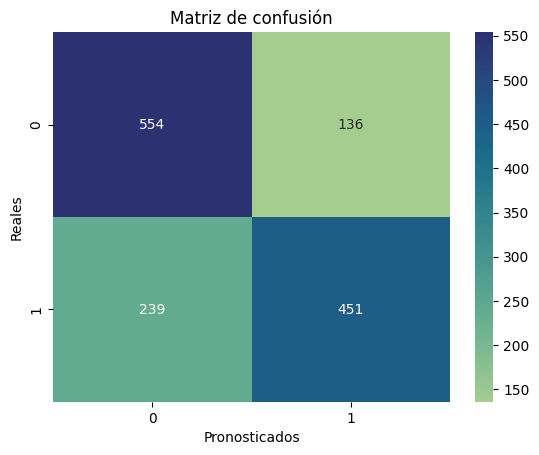

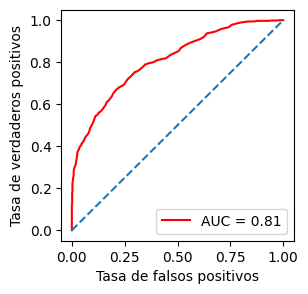

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un modelo XGBClassifier
model = RandomForestClassifier()

# Entrenamiento
model.fit(X_train, y_train)

# Predicciones sobre el conjunto de pruebas
y_pred = model.predict(X_test)

# Calcular precisión
evaluate_model(y_test,y_pred)

# Separar con espacios
print("\n\n\n")

# Graficar AUC-ROC
y_proba=model.predict_proba(X_test)
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test,y_proba[:,1])
roc_auc = auc(false_positive_rate, true_positive_rate)
plot_roc_(false_positive_rate,true_positive_rate,roc_auc)

**Conclusiones**<br>

El modelo Random Forest fue un buen clasificador de clientes buenos y malos. Estas fueron sus métricas:

Average Accuracy (scoring: accuracy): 0.7489<br>
Average Precision (scoring: precision_macro): 0.7503<br>
Average Recall (scoring: recall_macro): 0.7451